To see sensitivities, run the `mesh_sensitivity.py`

In [1]:
import os
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from globals import main_dir,data_dir, plot_dir, res_dir
import plotting_routines


## Wake-Length  (\# Periods)

In [2]:
# extracting data:
res_dir : Path

wake_length_dir = res_dir.joinpath('sensitivity/wake_length')

assert wake_length_dir.exists(), "Folder does not exist!"

wl_dfs = {}

for wl_file in os.listdir(wake_length_dir):
    wl_fpath = wake_length_dir.joinpath(wl_file)
    if wl_fpath.suffix != '.csv': continue
    if 'n=' not in wl_file: 
        wl_sum = pd.read_csv(wl_fpath)
    else:
        i = int(re.search(r'n=(\d+)', wl_file).group(1))
        wl_dfs[i] = pd.read_csv(wl_fpath)


#### Summary Plot

In [3]:
#  options
wl_sum.columns

Index(['i', 'CT', 'TC', 'CP', 'PC', 'CQ', 'QC', 'eta', 'it'], dtype='object')

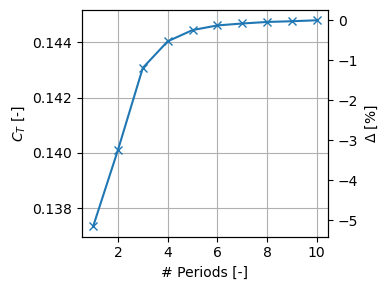

In [4]:
# summary plot
col = 'CT'
lbl = '$' + '_'.join(list(col)) + '$'
err_acc = 0.001

fig, ax = plt.subplots(figsize=(4,3))

ax.plot(wl_sum['i'], wl_sum[col], 'x-', label='uniform')

ax.set_ylabel(rf'{lbl} [-]')
ax.set_xlabel(r'# Periods [-]')
ax.grid()

# Secondary y-axis with % difference from first value
ax2 = ax.twinx()

first_val = wl_sum[col].iloc[-1]
pct_diff = (wl_sum[col] - first_val) / abs(first_val) * 100

ax2.plot(wl_sum['i'], pct_diff, alpha=0)  # invisible, just to set the scale
ax2.set_ylabel(r'$\Delta$ [%]')

# Sync the secondary axis limits to match the primary
def sync_axes(ax_primary, ax_secondary, ref_val):
    y1_min, y1_max = ax_primary.get_ylim()
    ax_secondary.set_ylim(
        (y1_min - ref_val) / abs(ref_val) * 100,
        (y1_max - ref_val) / abs(ref_val) * 100
    )

sync_axes(ax, ax2, first_val)
ax.callbacks.connect('ylim_changed', lambda _: sync_axes(ax, ax2, first_val))

fig.tight_layout()

fig.savefig(wake_length_dir.joinpath(f'summary_plot_{col}_wL.pdf'))

#### Distributions

In [5]:
# options

wl_dfs[1].columns

Index(['r_R', 'alpha', 'phi', 'Cl', 'Cd', 'gamma', 'Cy', 'Cx', 'a', 'aline',
       'V_i_x', 'V_i_y', 'V_i_z'],
      dtype='object')

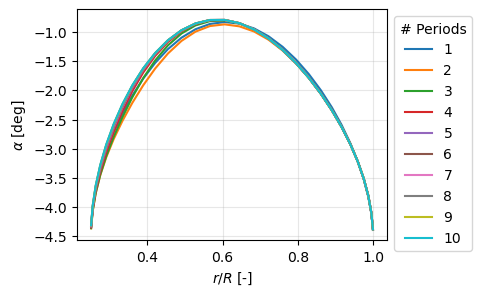

In [6]:
col = 'alpha'

fig, ax = plt.subplots(figsize=(4,3))

for i, wl_df in wl_dfs.items():
    # if i==1: continue
    plotting_routines.distribution(col, wl_df, ax, label=i)

ax.grid(True)
lgd = ax.legend(title='# Periods', bbox_to_anchor=(1, 1), loc='upper left')
fig.savefig(wake_length_dir.joinpath(f'dist_plot_{col}_wl.pdf'),
            bbox_extra_artists=(lgd,), bbox_inches='tight')


## Wake-Resolution

In [7]:
# extracting data:
res_dir : Path

wake_res_dir = res_dir.joinpath('sensitivity/wake_res')

assert wake_res_dir.exists(), "Folder does not exist!"

wr_dfs = {}

for wr_file in os.listdir(wake_res_dir):
    wr_fpath = wake_res_dir.joinpath(wr_file)
    if wr_fpath.suffix != '.csv': continue
    if 'n=' not in wr_file: 
        wr_sum = pd.read_csv(wr_fpath)
    else:
        i = int(re.search(r'n=(\d+)', wr_file).group(1))
        wr_dfs[i] = pd.read_csv(wr_fpath)



#### Summary

In [8]:
#  options
wr_sum.columns

Index(['CT', 'TC', 'CP', 'PC', 'CQ', 'QC', 'eta', 'it', 'i'], dtype='object')

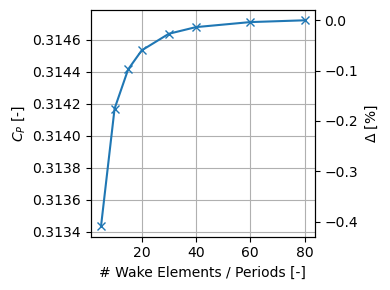

In [9]:
# summary plot
col = 'CP'
lbl = '$' + '_'.join(list(col)) + '$'
err_acc = 0.001

fig, ax = plt.subplots(figsize=(4,3))

ax.plot(wr_sum['i'], wr_sum[col], 'x-', label='uniform')

ax.set_ylabel(rf'{lbl} [-]')
ax.set_xlabel(r'# Wake Elements / Periods [-]')
ax.grid()

# Secondary y-axis with % difference from first value
ax2 = ax.twinx()

first_val = wr_sum[col].iloc[-1]
pct_diff = (wr_sum[col] - first_val) / abs(first_val) * 100

ax2.plot(wr_sum['i'], pct_diff, alpha=0)  # invisible, just to set the scale
ax2.set_ylabel(r'$\Delta$ [%]')

# Sync the secondary axis limits to match the primary
def sync_axes(ax_primary, ax_secondary, ref_val):
    y1_min, y1_max = ax_primary.get_ylim()
    ax_secondary.set_ylim(
        (y1_min - ref_val) / abs(ref_val) * 100,
        (y1_max - ref_val) / abs(ref_val) * 100
    )

sync_axes(ax, ax2, first_val)
ax.callbacks.connect('ylim_changed', lambda _: sync_axes(ax, ax2, first_val))

fig.tight_layout()

fig.savefig(wake_res_dir.joinpath(f'summary_plot_{col}_wr.pdf'))

#### Distributions

In [10]:
# options

wr_dfs[list(wr_dfs.keys())[0]].columns

Index(['r_R', 'alpha', 'phi', 'Cl', 'Cd', 'gamma', 'Cy', 'Cx', 'a', 'aline',
       'V_i_x', 'V_i_y', 'V_i_z'],
      dtype='object')

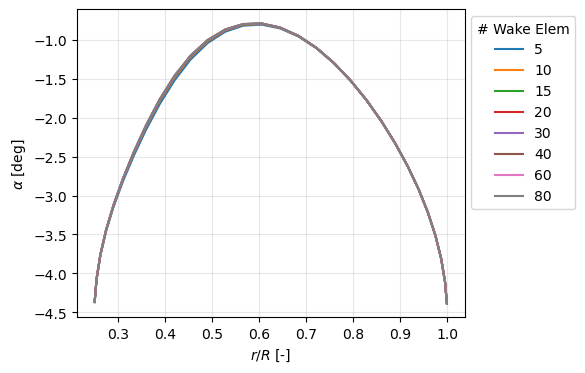

In [11]:
col = 'alpha'

fig, ax = plt.subplots(figsize=(5,4))

for i, wr_df in wr_dfs.items():
    plotting_routines.distribution(col, wr_df, ax, label=i)

ax.grid(True)
lgd = ax.legend(title='# Wake Elem', bbox_to_anchor=(1, 1), loc='upper left')
fig.savefig(wake_length_dir.joinpath(f'dist_plot_{col}_wr.pdf'),
            bbox_extra_artists=(lgd,), bbox_inches='tight')


## Blade Resolution

In [12]:
# extracting data:
res_dir : Path

blade_res_dir = res_dir.joinpath('sensitivity/blade_res')

assert blade_res_dir.exists(), "Folder does not exist!"

br_dfs = {}
br_dfs_c = {}

for br_file in os.listdir(blade_res_dir):
    br_fpath = blade_res_dir.joinpath(br_file)
    if br_fpath.suffix != '.csv': continue
    if "_c." not in br_file:
        if 'n=' not in br_file: 
            br_sum = pd.read_csv(br_fpath)
        else:
            i = int(re.search(r'n=(\d+)', br_file).group(1))
            br_dfs[i] = pd.read_csv(br_fpath)
    else:
        if 'n=' not in br_file:     
            br_sum_c = pd.read_csv(br_fpath)
        else:
            i = int(re.search(r'n=(\d+)', br_file).group(1))
            br_dfs_c[i] = pd.read_csv(br_fpath)


#### Summary

In [13]:
#  options
br_sum.columns

Index(['i', 'CT', 'TC', 'CP', 'PC', 'CQ', 'QC', 'eta', 'it'], dtype='object')

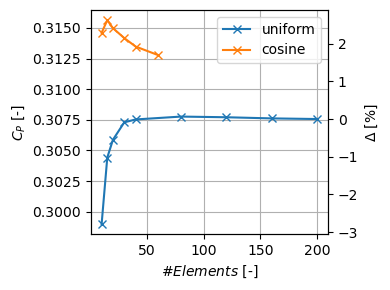

In [14]:
# summary plot
col = 'CP'
lbl = '$' + '_'.join(list(col)) + '$'
err_acc = 0.001

fig, ax = plt.subplots(figsize=(4,3))

ax.plot(br_sum['i'], br_sum[col], 'x-', label='uniform')
ax.plot(br_sum_c['i'], br_sum_c[col], 'x-', label='cosine')

ax.set_ylabel(rf'{lbl} [-]')
ax.set_xlabel(r'$\# Elements$ [-]')
ax.grid()
ax.legend()
# Secondary y-axis with % difference from first value
ax2 = ax.twinx()

first_val = br_sum[col].iloc[-1]
pct_diff = (br_sum[col] - first_val) / abs(first_val) * 100

ax2.plot(br_sum['i'], pct_diff, alpha=0)  # invisible, just to set the scale
ax2.set_ylabel(r'$\Delta$ [%]')

# Sync the secondary axis limits to match the primary
def sync_axes(ax_primary, ax_secondary, ref_val):
    y1_min, y1_max = ax_primary.get_ylim()
    ax_secondary.set_ylim(
        (y1_min - ref_val) / abs(ref_val) * 100,
        (y1_max - ref_val) / abs(ref_val) * 100
    )

sync_axes(ax, ax2, first_val)
ax.callbacks.connect('ylim_changed', lambda _: sync_axes(ax, ax2, first_val))

fig.tight_layout()

# fig.savefig(blade_res_dir.joinpath(f'summary_plot_{col}_br.pdf'))

#### Distribution

In [15]:
# options

br_dfs[list(br_dfs.keys())[0]].columns

Index(['r_R', 'alpha', 'phi', 'Cl', 'Cd', 'gamma', 'Cy', 'Cx', 'a', 'aline',
       'V_i_x', 'V_i_y', 'V_i_z'],
      dtype='object')

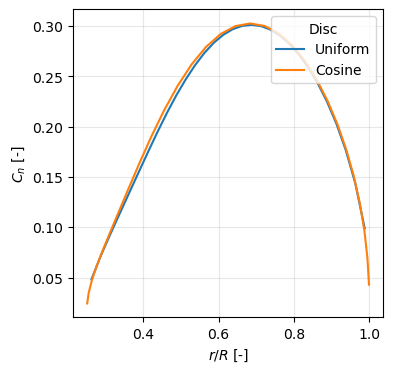

In [16]:
col = 'Cx'

fig, ax = plt.subplots(figsize=(4,4))

plotting_routines.distribution(col, br_dfs[30], ax, label='Uniform')
plotting_routines.distribution(col, br_dfs_c[30], ax, label='Cosine')

ax.grid(True)
# ax.legend()
lgd = ax.legend(title='Disc', loc='upper right')
fig.savefig(blade_res_dir.joinpath(f'dist_plot_{col}_br.pdf'),
            bbox_extra_artists=(lgd,), bbox_inches='tight')

## a_wake

In [17]:
a_wake_res_dir = res_dir.joinpath('sensitivity/a_wake')

assert a_wake_res_dir.exists(), "Folder does not exist!"

aw_dfs = {}

for aw_file in os.listdir(a_wake_res_dir):
    aw_fpath = a_wake_res_dir.joinpath(aw_file)
    if aw_fpath.suffix != '.csv': continue

    if 'n=' not in aw_file: 
        aw_sum = pd.read_csv(aw_fpath)
    else:
        i = str(re.search(r'n=([0-9]*\.?[0-9]+)', aw_file).group(1))[:4]
        aw_dfs[i] = pd.read_csv(aw_fpath)

6


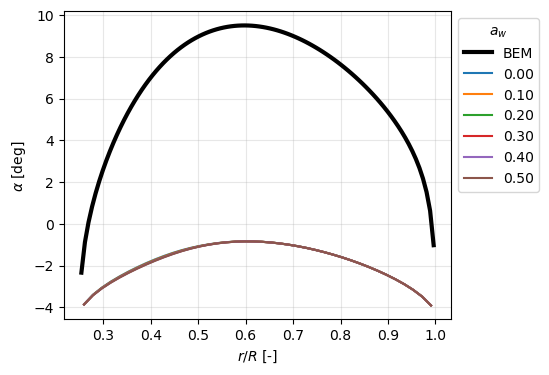

In [18]:
col = 'alpha'

fig, ax = plt.subplots(figsize=(5,4))
print(len(aw_dfs.items()))
bem_data = pd.read_csv("data/BEM_data_1.2.csv")
plt.plot(bem_data["r_R"], bem_data["alpha"],label = "BEM",color="black",linewidth=3)
for i, aw_df in aw_dfs.items():
    plotting_routines.distribution(col, aw_df, ax, label=i)

ax.grid(True)
lgd = ax.legend(title=r'$a_w$', bbox_to_anchor=(1, 1), loc='upper left')
fig.savefig(a_wake_res_dir.joinpath(f'dist_plot_{col}_aw.pdf'),
            bbox_extra_artists=(lgd,), bbox_inches='tight')

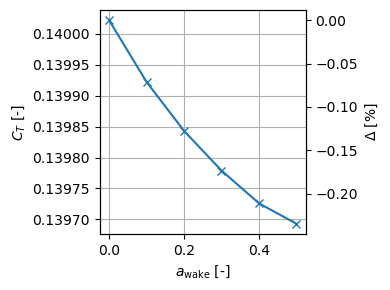

In [19]:
# summary plot
col = 'CT'
lbl = '$' + '_'.join(list(col)) + '$'
err_acc = 0.001

fig, ax = plt.subplots(figsize=(4,3))

ax.plot(aw_sum['i'], aw_sum[col], 'x-', label='uniform')

ax.set_ylabel(rf'{lbl} [-]')
ax.set_xlabel(r'$a_\text{wake}$ [-]')
ax.grid()

# Secondary y-axis with % difference from first value
ax2 = ax.twinx()

first_val = aw_sum[col].iloc[0]
pct_diff = (aw_sum[col] - first_val) / abs(first_val) * 100

ax2.plot(aw_sum['i'], pct_diff, alpha=0)  # invisible, just to set the scale
ax2.set_ylabel(r'$\Delta$ [%]')

# Sync the secondary axis limits to match the primary
def sync_axes(ax_primary, ax_secondary, ref_val):
    y1_min, y1_max = ax_primary.get_ylim()
    ax_secondary.set_ylim(
        (y1_min - ref_val) / abs(ref_val) * 100,
        (y1_max - ref_val) / abs(ref_val) * 100
    )

sync_axes(ax, ax2, first_val)
ax.callbacks.connect('ylim_changed', lambda _: sync_axes(ax, ax2, first_val))

fig.tight_layout()

fig.savefig(a_wake_res_dir.joinpath(f'summary_plot_{col}_awake.pdf'))